In [1]:
import os
os.chdir('../../../../..')

In [2]:
import numpy as np
import hdbscan

from sklearn.cluster import AgglomerativeClustering, SpectralClustering, DBSCAN
from kmedoids import KMedoids
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform

from src.datasets import QM9Dataset
from src.helper_functions import plot_molecules_with_py3dmol, create_chemiscope_viewer, plot_distance_matrix_projection, evaluate_distance_matrix_clustering_sweep, average_numeric_by_cluster, evaluate_hdbscan_grid

projection_method = "MDS"

In [3]:
qm9 = QM9Dataset(limit=5000, descriptors=["soap"])
df = qm9.load()

dist_matrix = qm9.get_distance_matrix(
    descriptor="soap",
    dist_type="soap_kernel",
)

2026-05-09 14:44:42.395 | INFO     | src.datasets:_load_full_qm9_df:816 - Loading cached full QM9 dataset from: data/QM9/dataset_cleaned.parquet
2026-05-09 14:44:42.803 | INFO     | src.datasets:_sample_qm9_df:999 - QM9 sampling complete: strategy=stratified, requested_limit=5000, returned_rows=5000, sampling on columns=['num_atoms', 'gap'].
2026-05-09 14:44:42.803 | INFO     | src.datasets:_add_requested_descriptors:201 - Applying requested QM9 descriptors to sampled dataframe (rows=5000).
2026-05-09 14:44:42.809 | INFO     | src.features:compute_soap_outputs:394 - Computing SOAP (rcut=6.0, nmax=8, lmax=6, normalize=True)...
2026-05-09 14:44:46.606 | SUCCESS  | src.datasets:add_soap:1192 - Added SOAP embeddings and matrices.
2026-05-09 14:44:46.608 | INFO     | src.datasets:_add_requested_descriptors:212 - Added descriptor column(s): ['soap_embedding', 'soap_matrix']
2026-05-09 14:44:46.613 | INFO     | src.datasets:_load_with_descriptor_filter:856 - QM9 descriptor null-filtering comp

# Determining the best number of clusters for each clustering method

In [ ]:
out = evaluate_distance_matrix_clustering_sweep(
    dist_matrix=dist_matrix,
    fingerprint="soap",
    distance_metric="soap_kernel",
    dataset_name="qm9",
)

# Hiercical Clustering on Distance Matrix

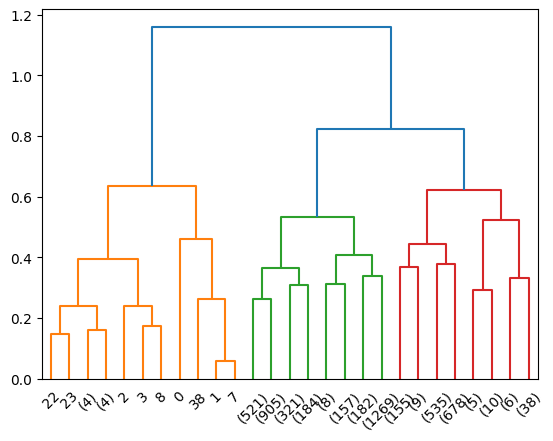

In [4]:
condensed_dist = squareform(dist_matrix)
Z = linkage(condensed_dist, method='complete')
a = dendrogram(
    Z,
    truncate_mode='level',
    p=4                 
)

In [5]:
model_hier = AgglomerativeClustering(metric='precomputed', n_clusters=4, linkage='complete')
labels_hier = model_hier.fit_predict(dist_matrix)
print(np.unique(labels_hier, return_counts=True))
df = df.with_columns(labels_hier=labels_hier)

(array([0, 1, 2, 3]), array([1436,    4, 3547,   13]))


In [ ]:
create_chemiscope_viewer(df, dist_matrix, labels_hier, projection_method)

/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


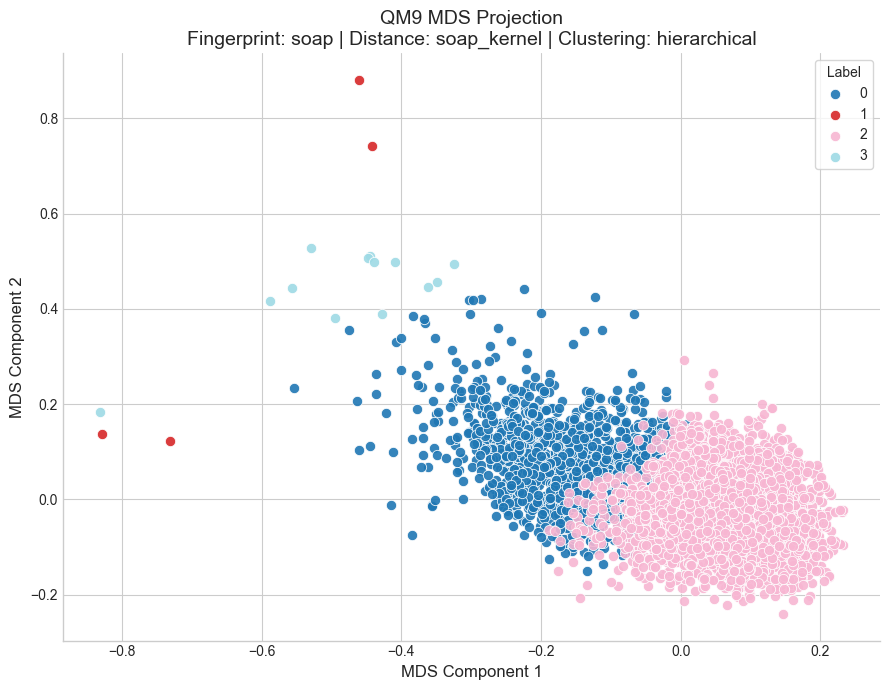

2026-05-09 15:28:46.931 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:609 - Saved MDS projection plot to figures/qm9/clustering/soap_kernel/soap/mds_hierarchical_projection.png


In [6]:
_=plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="soap",
    distance_metric="soap_kernel",
    projection_method=projection_method,
    dataset_name="qm9",
    labels=labels_hier,
    clustering_method="hierarchical"
)

In [ ]:
d = average_numeric_by_cluster(df, "labels_hier")

# KMedoids

In [ ]:
model_km = KMedoids(n_clusters=3, metric="precomputed")
labels_km = model_km.fit_predict(dist_matrix)
df = df.with_columns(labels_km=labels_km)
print(np.unique(labels_km, return_counts=True))

In [11]:
create_chemiscope_viewer(df, dist_matrix, labels_km, projection_method)

/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
2026-05-09 11:52:46.633 | INFO     | src.helper_functions:create_chemiscope_viewer:1217 - Assembling properties for Chemiscope...
2026-05-09 11:52:46.707 | INFO     | src.helper_functions:create_chemiscope_viewer:1312 - Generating Chemiscope widget...
2026-05-09 11:52:47.033 | SUCCESS  | src.helper_functions:create_chemiscope_viewer:1343 - Saved Chemiscope input to: qm9_MDS_clust

<ChemiscopeWidget(meta={'name': 'QM9 - MDS Clustering'}, settings={'map': {'x': {'property': 'MDS_1'}, 'y': {'…

/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


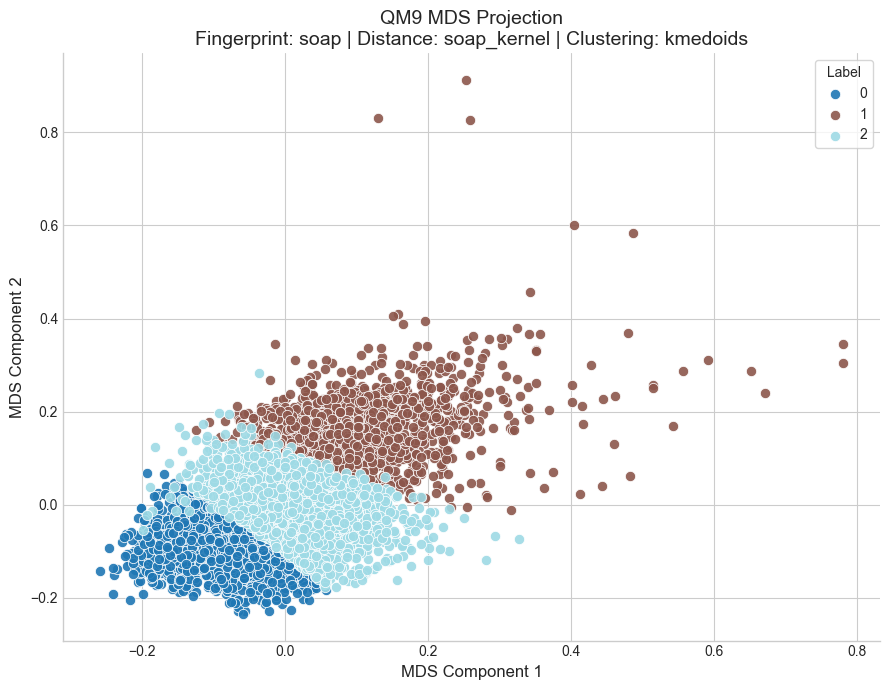

2026-05-09 11:58:23.183 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:605 - Saved MDS projection plot to figures/qm9/clustering/soap_kernel/soap/mds_kmedoids_projection.png


{'coords': array([[ 0.77944679,  0.30398259],
        [ 0.25867737,  0.82630997],
        [ 0.25229911,  0.91276685],
        ...,
        [ 0.08829694,  0.10136043],
        [-0.08730325, -0.01221868],
        [ 0.06086139, -0.06424451]], shape=(5000, 2)),
 'figure_path': PosixPath('figures/qm9/clustering/soap_kernel/soap/mds_kmedoids_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/soap_kernel/soap'),
 'clustering_method': 'kmedoids'}

In [12]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="soap",
    distance_metric="soap_kernel",
    projection_method=projection_method,
    dataset_name="qm9",
    labels=labels_km,
    clustering_method="kmedoids"
)

In [13]:
average_numeric_by_cluster(df, "labels_km")

shape: (3, 72)
┌───────────┬───────┬─────────────────┬─────────────┬────────────┬─────────┬─────────┬─────────────────┬─────────────────┬────────────────┬───────────┬────────────────┬──────────────┬────────────────┬───────────┬──────────────┬────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬────────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬─────────────┬────────────────┬──────────────┬─────────────┬────────────────┬────────────────┬──────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬──

labels_km,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
u64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
0,1836,0.71088,0.0,124.85512,0.367647,25.931373,0.922823,12.809169,8.922113,1.983115,0.004357,0.0,1.734749,20.740196,2.085487,2.567538,0.027402,0.084679,0.887919,0.832244,1.49183,7.343682,0.20098,0.608388,6.377996,6.208061,14.601852,1.262492,0.0,0.484205,0.0,0.040305,0.05719,0.001634,0.009804,0.096405,0.497821,0.0,2.17713,79.769657,-6.51588,1.019323,7.535181,1184.574527,4.831384,-10918.821426,-10918.580916,-10918.555205,-10919.732644,33.882695,-84.856733,-85.407678,-85.909806,-78.849511,2.766596,1.429616,1.17904,0.0,93.409586,0.43573,6.154684,14.601852,717,"""Acyclic""",6.154684,219,"""C1CC1""",8.986928,1,null,0.0
1,1167,0.823184,0.0,119.449871,0.028278,51.043702,0.725744,12.951566,8.575835,0.978578,0.619537,0.084833,3.400171,15.133676,1.994567,2.041988,0.115148,0.542235,0.342617,1.005141,2.735219,5.38389,0.684662,2.66838,1.822622,6.553556,12.193659,1.257204,0.009426,0.137961,0.123393,0.281919,0.137104,0.001714,0.061697,0.096829,0.33419,0.006855,3.212684,70.74114,-6.471492,-0.584285,5.887233,1210.180491,3.106537,-11404.649581,-11404.427769,-11404.402073,-11405.558759,29.094416,-65.322173,-65.675055,-66.032559,-60.958745,5.05177,1.688434,1.320444,1.179949,22.365039,58.783205,18.851757,12.193659,336,"""Acyclic""",18.851757,46,"""C1CCCC1""",32.562125,1,null,0.0
2,1997,0.780176,0.0,122.132699,-0.109164,38.220831,0.878845,12.842648,8.72659,1.759139,0.071607,0.023035,2.562344,17.77967,2.076024,2.18678,0.071524,0.18203,0.746446,0.922384,2.111167,6.311968,0.475714,1.10015,4.588383,6.31998,13.655984,1.266483,0.000501,0.347021,0.011517,0.122684,0.156234,0.002504,0.06009,0.166249,0.63345,0.0,2.882582,73.097927,-6.620668,0.148867,6.769535,1173.250707,3.870026,-11244.224916,-11243.997875,-11243.97219,-11245.132469,30.906117,-73.811548,-74.255881,-74.677905,-68.714277,3.466785,1.416005,1.141601,0.0,82.223335,7.160741,10.615924,13.655984,778,"""Acyclic""",10.615924,222,"""C1CC1""",11.16675,1,null,0.0


# Spectral

In [7]:
kernel_matrix = 1.0 - (dist_matrix**2 / 2.0)
np.fill_diagonal(kernel_matrix, 1.0)
kernel_matrix = np.clip(kernel_matrix, a_min=0.0, a_max=1.0)
kernel_matrix = (kernel_matrix + kernel_matrix.T) / 2.0

gaussian_kernel = np.exp(-dist_matrix**2 / (2 * 1.0**2))

In [8]:
model_spectral = SpectralClustering(
                n_clusters=3,
                affinity="precomputed",
                assign_labels='kmeans',
                random_state=42,
            )

labels_spectral = model_spectral.fit_predict(gaussian_kernel)
df = df.with_columns(labels_spectral=labels_spectral)
print(np.unique(labels_spectral, return_counts=True))

(array([0, 1, 2], dtype=int32), array([2215, 1298, 1487]))


In [9]:
create_chemiscope_viewer(df, dist_matrix, labels_spectral, 'MDS')

2026-05-12 17:13:15.255 | INFO     | src.helper_functions:create_chemiscope_viewer:1144 - Running MDS dimensionality reduction...
2026-05-12 17:13:15.257 | INFO     | src.helper_functions:create_chemiscope_viewer:1153 - Converting structures/molecules to ASE Atoms for Chemiscope...
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
2026-05-12 17:18:24.893 | INFO     | src.helper_functions:create_chemiscope_viewer:1221 - Assemblin

<ChemiscopeWidget(meta={'name': 'QM9 - MDS Clustering'}, settings={'map': {'x': {'property': 'MDS_1'}, 'y': {'…

/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


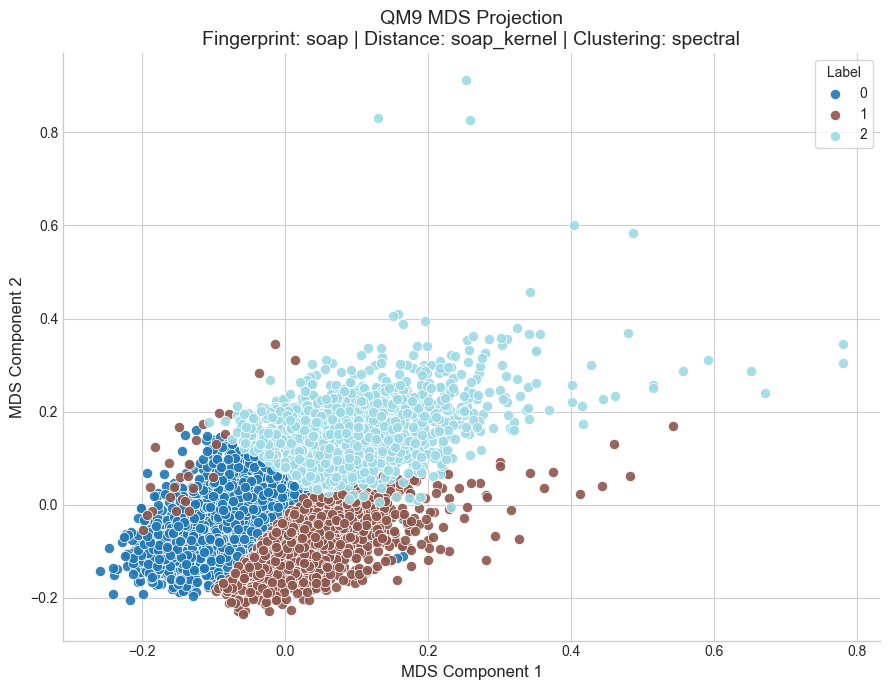

2026-05-09 12:04:57.083 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:605 - Saved MDS projection plot to figures/qm9/clustering/soap_kernel/soap/mds_spectral_projection.png


In [17]:
_=plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="soap",
    distance_metric="soap_kernel",
    projection_method=projection_method,
    dataset_name="qm9",
    labels=labels_spectral,
    clustering_method="spectral"
)

In [10]:
_=average_numeric_by_cluster(df, "labels_spectral")

shape: (3, 72)
┌────────────────┬───────┬────────────────┬─────────────┬────────────┬─────────┬─────────┬────────────────┬────────────────┬────────────────┬───────────┬────────────────┬──────────────┬────────────────┬───────────┬──────────────┬────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬────────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬─────────────┬────────────────┬──────────────┬─────────────┬────────────────┬────────────────┬──────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬───────────────┬─

# DBSCAN 

In [19]:
model_db = DBSCAN(
    eps=0.4,
    min_samples=3,
    metric='precomputed',
)

labels_db = model_db.fit_predict(dist_matrix)
df = df.with_columns(labels_db=labels_db)
print(np.unique(labels_db, return_counts=True))

(array([0]), array([5000]))


In [20]:
create_chemiscope_viewer(df, dist_matrix, labels_db, 'PCA')

2026-05-09 12:04:58.010 | INFO     | src.helper_functions:create_chemiscope_viewer:1140 - Running PCA dimensionality reduction...
2026-05-09 12:04:58.012 | INFO     | src.helper_functions:create_chemiscope_viewer:1149 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-05-09 12:05:51.904 | INFO     | src.helper_functions:create_chemiscope_viewer:1217 - Assembling properties for Chemiscope...
2026-05-09 12:05:51.928 | INFO     | src.helper_functions:create_chemiscope_viewer:1312 - Generating Chemiscope widget...
2026-05-09 12:05:52.207 | SUCCESS  | src.helper_functions:create_chemiscope_viewer:1343 - Saved Chemiscope input to: qm9_PCA_clustering.json
2026-05-09 12:05:52.282 | WARNING  | src.helper_functions:create_chemiscope_viewer:1349 - If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


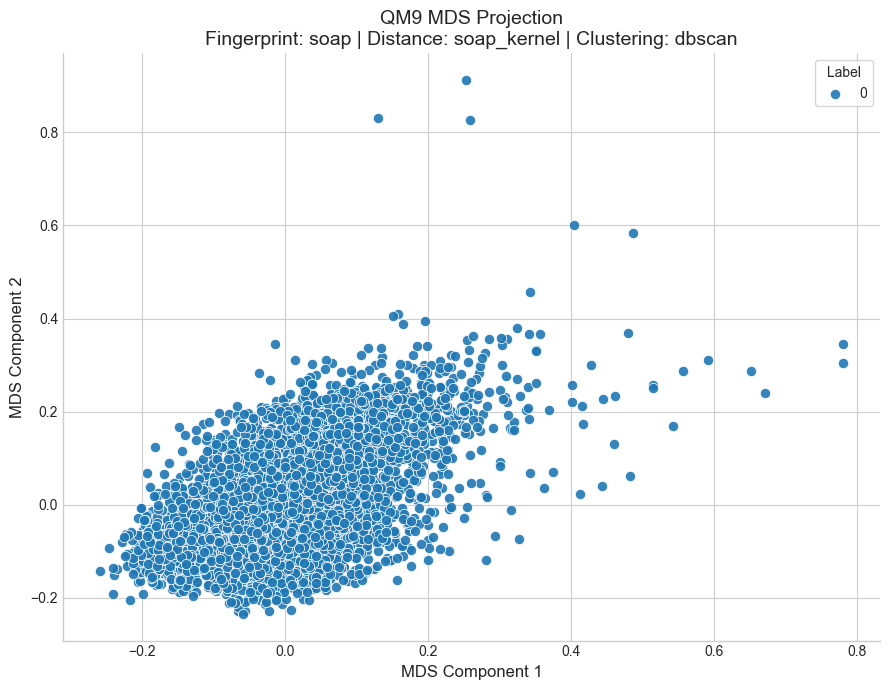

2026-05-09 12:12:03.195 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:605 - Saved MDS projection plot to figures/qm9/clustering/soap_kernel/soap/mds_dbscan_projection.png


{'coords': array([[ 0.77944679,  0.30398259],
        [ 0.25867737,  0.82630997],
        [ 0.25229911,  0.91276685],
        ...,
        [ 0.08829694,  0.10136043],
        [-0.08730325, -0.01221868],
        [ 0.06086139, -0.06424451]], shape=(5000, 2)),
 'figure_path': PosixPath('figures/qm9/clustering/soap_kernel/soap/mds_dbscan_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/soap_kernel/soap'),
 'clustering_method': 'dbscan'}

In [21]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="soap",
    distance_metric="soap_kernel",
    projection_method=projection_method,
    dataset_name="qm9",
    labels=labels_db,
    clustering_method="dbscan"
)

In [22]:
d =average_numeric_by_cluster(df, "labels_db")

shape: (1, 74)
┌───────────┬───────┬────────────────┬─────────────┬────────────┬────────┬─────────┬────────────────┬────────────────┬───────────────┬───────────┬───────────────┬──────────────┬───────────────┬───────────┬──────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬───────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬─────────────┬───────────┬───────────────┬───────────────┬──────────────┬─────────────┬───────────────┬───────────────┬──────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬─

# HDBSCAN

In [23]:
a = evaluate_hdbscan_grid(dist_matrix)


Top configurations:

mcs=150, ms=1, clusters=2, noise=0.23, persistence=0.128, score=0.099
mcs=60, ms=1, clusters=3, noise=0.21, persistence=0.100, score=0.079
mcs=120, ms=1, clusters=3, noise=0.21, persistence=0.097, score=0.077
mcs=80, ms=1, clusters=3, noise=0.21, persistence=0.094, score=0.075
mcs=40, ms=4, clusters=3, noise=0.29, persistence=0.093, score=0.066
mcs=60, ms=15, clusters=2, noise=0.36, persistence=0.101, score=0.065
mcs=20, ms=1, clusters=4, noise=0.21, persistence=0.074, score=0.058
mcs=80, ms=8, clusters=2, noise=0.40, persistence=0.097, score=0.058
mcs=40, ms=20, clusters=2, noise=0.39, persistence=0.094, score=0.057
mcs=60, ms=6, clusters=3, noise=0.33, persistence=0.081, score=0.054
mcs=60, ms=10, clusters=2, noise=0.43, persistence=0.092, score=0.052
mcs=20, ms=15, clusters=3, noise=0.37, persistence=0.078, score=0.050
mcs=20, ms=10, clusters=3, noise=0.42, persistence=0.078, score=0.045
mcs=20, ms=10, clusters=3, noise=0.42, persistence=0.078, score=0.045
mcs=

In [48]:
clusterer = hdbscan.HDBSCAN(
        min_cluster_size=150,
        min_samples=1,
        metric='precomputed',
    )

labels_hdbscan = clusterer.fit_predict(dist_matrix.astype(np.float64))
df = df.with_columns(labels_hdbscan=labels_hdbscan)

In [25]:
create_chemiscope_viewer(df, dist_matrix, labels_hdbscan, 'PCA')

2026-05-09 12:12:48.935 | INFO     | src.helper_functions:create_chemiscope_viewer:1140 - Running PCA dimensionality reduction...
2026-05-09 12:12:48.936 | INFO     | src.helper_functions:create_chemiscope_viewer:1149 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-05-09 12:13:49.254 | INFO     | src.helper_functions:create_chemiscope_viewer:1217 - Assembling properties for Chemiscope...
2026-05-09 12:13:49.280 | INFO     | src.helper_functions:create_chemiscope_viewer:1312 - Generating Chemiscope widget...
2026-05-09 12:13:50.111 | SUCCESS  | src.helper_functions:create_chemiscope_viewer:1343 - Saved Chemiscope input to: qm9_PCA_clustering.json
2026-05-09 12:13:50.197 | WARNING  | src.helper_functions:create_chemiscope_viewer:1349 - If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


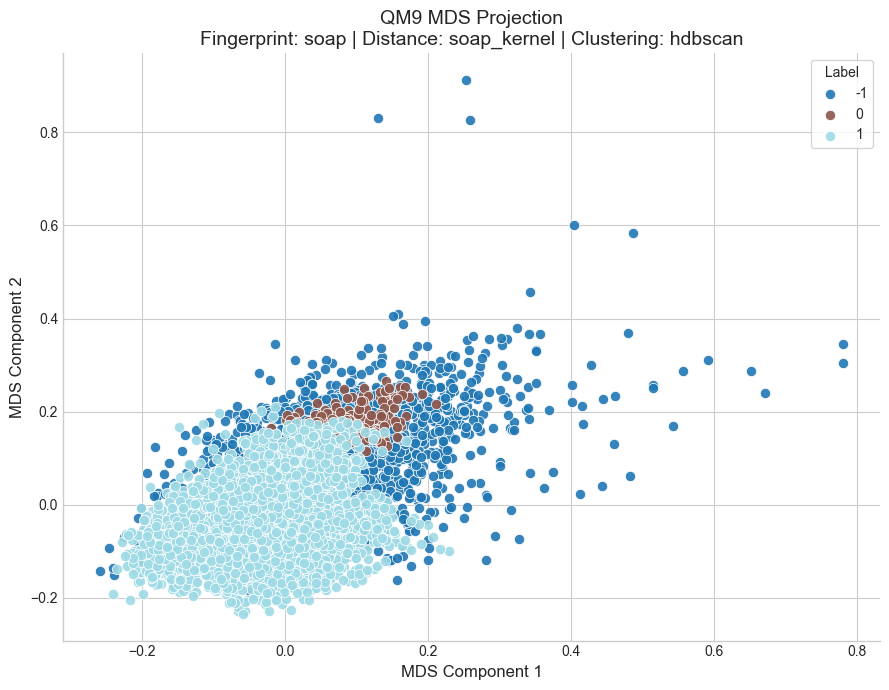

2026-05-09 14:24:47.576 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:605 - Saved MDS projection plot to figures/qm9/clustering/soap_kernel/soap/mds_hdbscan_projection.png


In [49]:
_=plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="soap",
    distance_metric="soap_kernel",
    projection_method=projection_method,
    dataset_name="qm9",
    labels=labels_hdbscan,
    clustering_method="hdbscan"
)

In [27]:
average_numeric_by_cluster(df, "labels_hdbscan")

shape: (7, 75)
┌───────────────┬───────┬───────────────┬─────────────┬────────────┬─────────┬─────────┬───────────────┬───────────────┬───────────────┬───────────┬───────────────┬──────────────┬───────────────┬───────────┬──────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬──────────────┬──────────────┬──────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬──────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬─────────────┬───────────┬──────────────┬───────────┬──────────────┬──────────────┬─────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬

labels_hdbscan,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,labels_km,labels_spectral,labels_db,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
-1,2156,0.776426,0.0,120.777829,0.066327,42.028293,0.810009,12.889999,8.647959,1.273655,0.30705,0.044063,2.802412,17.039425,2.023355,2.361317,0.106656,0.320158,0.573186,0.915121,2.295455,5.890538,0.67115,1.693878,3.480519,6.535714,12.863173,1.258631,0.004174,0.239332,0.04731,0.211039,0.138219,0.002319,0.057978,0.118738,0.486085,0.002319,2.876043,73.340213,-6.583722,-0.063914,6.519823,1236.200451,3.662212,-11194.47276,-11194.241006,-11194.215321,-11195.390598,30.856303,-71.424736,-71.838096,-72.242593,-66.54027,4.298279,1.527973,1.223882,0.492579,1.346475,1.204082,0.0,51.530612,29.267161,19.202226,12.863173,659,"""Acyclic""",19.202226,152,"""C1CCCC1""",20.686456,1,null,0.0
0,109,0.847482,0.0,124.192661,0.06422,53.724771,0.70482,13.019151,8.87156,1.06422,0.844037,0.220183,3.834862,15.155963,2.00877,1.899083,0.008869,0.760507,0.230625,1.174312,2.880734,6.137615,0.045872,3.880734,1.110092,6.40367,12.788991,1.257028,0.027523,0.110092,0.174312,0.256881,0.192661,0.0,0.018349,0.036697,0.146789,0.018349,3.592774,72.36,-6.11295,-0.886467,5.226408,1139.134338,3.080097,-12048.327605,-12048.112466,-12048.086789,-12049.220873,28.976743,-66.197531,-66.557071,-66.914498,-61.782648,3.645326,1.435552,0.992101,1.266055,1.0,2.0,0.0,13.761468,83.486239,2.752294,12.788991,62,"""c1c[nH]cn1""",8.256881,11,"""C1CCCCC1""",30.275229,1,null,0.0
1,27,1.08806,0.0,119.592593,0.037037,59.37037,0.827785,13.134511,8.444444,1.0,0.925926,0.62963,4.296296,11.555556,2.0,0.925926,0.028395,0.962346,0.009259,0.740741,2.962963,4.555556,0.148148,3.962963,0.037037,5.518519,12.518519,1.277947,0.0,0.037037,0.37037,0.111111,0.0,0.0,0.037037,0.0,0.074074,0.037037,3.489033,60.432222,-6.830159,-1.694866,5.135494,932.308639,2.064176,-12471.253002,-12471.074725,-12471.049154,-12472.097692,24.306593,-53.796201,-54.06048,-54.3298,-50.368505,3.76802,1.776,1.175617,3.0,1.0,2.0,0.0,7.407407,92.592593,0.0,12.518519,20,"""O=c1ccocc1""",14.814815,3,"""CC1CCCCC1""",55.555556,1,null,0.0
2,39,0.93246,0.0,123.410256,0.153846,66.538462,0.664716,12.981121,8.897436,1.153846,1.025641,0.153846,3.974359,14.0,2.021771,1.564103,0.0,0.99359,0.00641,1.641026,2.820513,6.128205,0.0,4.897436,0.025641,6.179487,13.025641,1.259016,0.0,0.051282,0.641026,0.461538,0.102564,0.0,0.0,0.0,0.025641,0.0,3.808377,72.625128,-5.930338,-1.122505,4.807624,1051.937456,2.778346,-12079.294947,-12079.097306,-12079.07169,-12080.159906,27.815949,-63.458525,-63.7955,-64.126276,-59.310777,3.220511,1.621123,1.04951,2.461538,1.0,2.0,0.0,10.25641,89.74359,0.0,13.025641,29,"""c1ccncc1""",10.25641,10,"""C1CCCCC1""",41.025641,1,null,0.0
3,22,0.789116,0.0,124.5,0.227273,46.727273,0.6715,12.964359,8.954545,1.136364,0.909091,0.0,3.363636,17.181818,2.015746,2.909091,0.009091,0.6171,0.37381,1.181818,2.818182,6.863636,0.045455,3.5,2.045455,6.590909,13.545455,1.2500

# KMeans

In [28]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

X = np.array(df['soap_embedding'].to_list())
pca = PCA(n_components=4)
X_pca = pca.fit_transform(X)

kmeans = KMeans(n_clusters=3)
labels_kmeans = kmeans.fit_predict(X_pca)
df = df.with_columns(labels_kmeans=labels_kmeans)

print(np.unique(labels_kmeans, return_counts=True))

(array([0, 1, 2], dtype=int32), array([2289,  927, 1784]))


In [29]:
create_chemiscope_viewer(df, X, labels_kmeans, 'PCA')

2026-05-09 12:20:04.172 | INFO     | src.helper_functions:create_chemiscope_viewer:1140 - Running PCA dimensionality reduction...
2026-05-09 12:20:04.174 | INFO     | src.helper_functions:create_chemiscope_viewer:1149 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-05-09 12:20:58.976 | INFO     | src.helper_functions:create_chemiscope_viewer:1217 - Assembling properties for Chemiscope...
2026-05-09 12:20:58.996 | INFO     | src.helper_functions:create_chemiscope_viewer:1312 - Generating Chemiscope widget...
2026-05-09 12:20:59.273 | SUCCESS  | src.helper_functions:create_chemiscope_viewer:1343 - Saved Chemiscope input to: qm9_PCA_clustering.json
2026-05-09 12:20:59.382 | WARNING  | src.helper_functions:create_chemiscope_viewer:1349 - If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

In [30]:
average_numeric_by_cluster(df, 'labels_kmeans')

shape: (3, 76)
┌───────────────┬───────┬───────────────┬─────────────┬────────────┬─────────┬─────────┬──────────────┬──────────────┬──────────────┬───────────┬──────────────┬──────────────┬──────────────┬───────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬──────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬─────────────┬───────────┬──────────────┬───────────┬──────────────┬──────────────┬──────────────┬─────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬

labels_kmeans,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,…,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,labels_km,labels_spectral,labels_db,labels_hdbscan,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i32,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
0,2289,0.723152,0.0,124.556138,0.266055,27.637833,0.920049,12.813148,8.896898,2.015291,0.004806,0.003932,1.854958,20.328091,2.089525,2.488423,0.03061,0.090175,0.879215,0.869375,1.587156,7.216689,0.21931,0.632154,6.190476,6.204893,14.538226,1.26374,0.0,0.486239,0.0,0.051551,0.065968,0.001311,0.01398,0.103976,…,2.250339,78.624753,-6.521714,0.937131,7.45882,1174.856456,4.69804,-10981.601706,-10981.364278,-10981.338565,-10982.510542,33.37892,-83.265669,-83.802922,-84.293866,-77.383384,2.857104,1.434281,1.183743,0.0,0.395806,0.310179,0.0,3.346876,93.228484,0.480559,6.290957,14.538226,885,"""Acyclic""",6.290957,253,"""C1CC1""",9.04325,1,null,0.0
1,927,0.841383,0.0,118.605178,-0.002157,52.838188,0.70858,12.970611,8.513484,0.973031,0.661273,0.102481,3.535059,14.580367,1.992777,1.878101,0.118017,0.578145,0.303838,1.010787,2.841424,5.196332,0.683927,2.746494,1.548004,6.498382,12.035599,1.258264,0.007551,0.12945,0.12945,0.285868,0.137001,0.001079,0.057174,0.084142,…,3.258819,69.435027,-6.513789,-0.689643,5.824155,1185.834002,2.951162,-11425.309542,-11425.093128,-11425.067432,-11426.211383,28.369931,-63.338045,-63.675765,-64.019556,-59.126835,5.410456,1.807943,1.419043,1.482201,1.0,1.959008,0.0,-0.634304,19.95685,62.135922,17.907228,12.035599,279,"""Acyclic""",17.907228,38,"""C1CCCC1""",33.764833,1,null,0.0
2,1784,0.778354,0.0,121.903027,-0.065583,39.944507,0.859559,12.850801,8.721413,1.558857,0.140135,0.022982,2.660874,17.488229,2.058412,2.257287,0.082989,0.229496,0.687515,0.90583,2.174888,6.185538,0.550448,1.36491,4.145179,6.412556,13.382848,1.264096,0.002803,0.285874,0.026345,0.148543,0.167601,0.003363,0.070067,0.171525,…,2.988217,73.234434,-6.597744,-0.010589,6.587176,1200.463329,3.775028,-11257.147482,-11256.917805,-11256.892126,-11258.061192,30.929402,-72.937285,-73.367689,-73.782168,-67.930396,3.555299,1.381114,1.098886,0.001682,1.865471,0.86435,0.0,0.870516,72.813901,14.013453,13.172646,13.382848,654,"""Acyclic""",13.172646,178,"""Acyclic""",13.172646,1,null,0.0


# Average Kernel

In [31]:
average_kernel_dist_matrix = qm9.get_distance_matrix(descriptor="soap_matrix", dist_type="average_kernel")

2026-05-09 12:20:59.564 | INFO     | src.datasets:get_distance_matrix:1313 - Calculating distance matrix for soap_matrix using average_kernel distance.


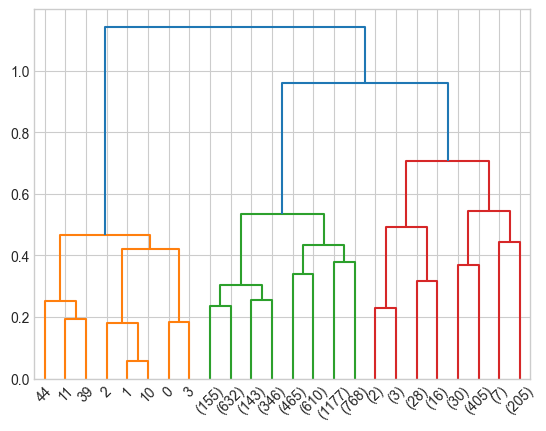

In [32]:
condensed_dist = squareform(average_kernel_dist_matrix)
Z = linkage(condensed_dist, method='complete')
a = dendrogram(
    Z,
    truncate_mode='level',
    p=4                 
)

In [33]:
model_hier_avg = AgglomerativeClustering(metric='precomputed', n_clusters=4, linkage='complete')
labels_hier_avg = model_hier_avg.fit_predict(average_kernel_dist_matrix)
print(np.unique(labels_hier_avg, return_counts=True))
df = df.with_columns(labels_hier_avg=labels_hier_avg)

(array([0, 1, 2, 3]), array([ 647,   49, 4296,    8]))


In [34]:
create_chemiscope_viewer(df, average_kernel_dist_matrix, labels_hier_avg, projection_method)

2026-05-09 12:36:28.386 | INFO     | src.helper_functions:create_chemiscope_viewer:1140 - Running MDS dimensionality reduction...
2026-05-09 12:36:28.391 | INFO     | src.helper_functions:create_chemiscope_viewer:1149 - Converting structures/molecules to ASE Atoms for Chemiscope...
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
2026-05-09 12:43:24.618 | INFO     | src.helper_functions:create_chemiscope_viewer:1217 - Assemblin

<ChemiscopeWidget(meta={'name': 'QM9 - MDS Clustering'}, settings={'map': {'x': {'property': 'MDS_1'}, 'y': {'…

/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


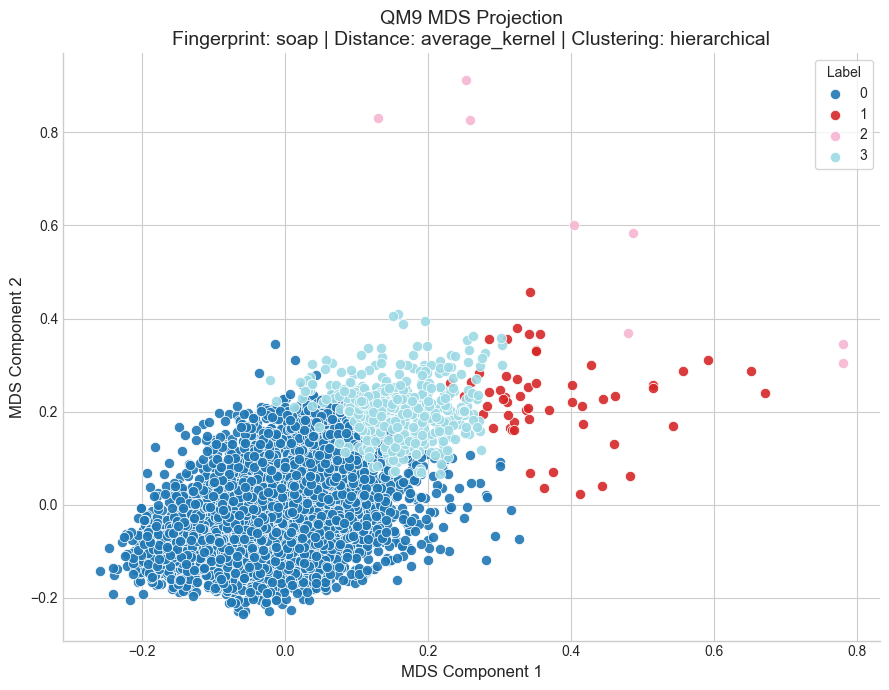

2026-05-09 12:49:39.564 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:605 - Saved MDS projection plot to figures/qm9/clustering/average_kernel/soap/mds_hierarchical_projection.png


{'coords': array([[ 0.77944685,  0.30398244],
        [ 0.25867659,  0.82631023],
        [ 0.25229845,  0.91276706],
        ...,
        [ 0.08829629,  0.1013606 ],
        [-0.08730449, -0.0122178 ],
        [ 0.06086098, -0.06424409]], shape=(5000, 2)),
 'figure_path': PosixPath('figures/qm9/clustering/average_kernel/soap/mds_hierarchical_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/average_kernel/soap'),
 'clustering_method': 'hierarchical'}

In [35]:
plot_distance_matrix_projection(
    dist_matrix=average_kernel_dist_matrix,
    fingerprint="soap",
    distance_metric="average_kernel",
    projection_method=projection_method,
    dataset_name="qm9",
    labels=labels_hier,
    clustering_method="hierarchical"
)

# ReMatch Kernel

In [36]:
rematch_kernel_dist_matrix = qm9.get_distance_matrix(descriptor="soap_matrix", dist_type="rematch_kernel")

2026-05-09 12:49:39.862 | INFO     | src.datasets:get_distance_matrix:1313 - Calculating distance matrix for soap_matrix using rematch_kernel distance.


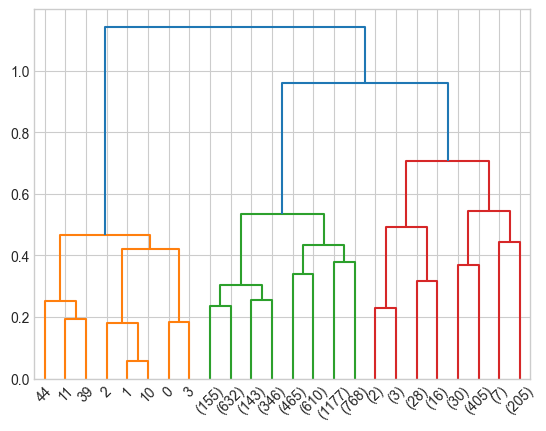

In [37]:
condensed_dist = squareform(rematch_kernel_dist_matrix)
Z = linkage(condensed_dist, method='complete')
a = dendrogram(
    Z,
    truncate_mode='level',
    p=4                 
)

In [38]:
model_hier_rematch = AgglomerativeClustering(metric='precomputed', n_clusters=4, linkage='complete')
labels_hier_rematch = model_hier_rematch.fit_predict(rematch_kernel_dist_matrix)
print(np.unique(labels_hier_rematch, return_counts=True))
df = df.with_columns(labels_hier_rematch=labels_hier_rematch)

(array([0, 1, 2, 3]), array([ 647,   49, 4296,    8]))


In [39]:
create_chemiscope_viewer(df, rematch_kernel_dist_matrix, labels_hier_rematch, projection_method)

2026-05-09 13:09:16.944 | INFO     | src.helper_functions:create_chemiscope_viewer:1140 - Running MDS dimensionality reduction...
2026-05-09 13:09:16.945 | INFO     | src.helper_functions:create_chemiscope_viewer:1149 - Converting structures/molecules to ASE Atoms for Chemiscope...
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
2026-05-09 13:14:18.216 | INFO     | src.helper_functions:create_chemiscope_viewer:1217 - Assemblin

<ChemiscopeWidget(meta={'name': 'QM9 - MDS Clustering'}, settings={'map': {'x': {'property': 'MDS_1'}, 'y': {'…

/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


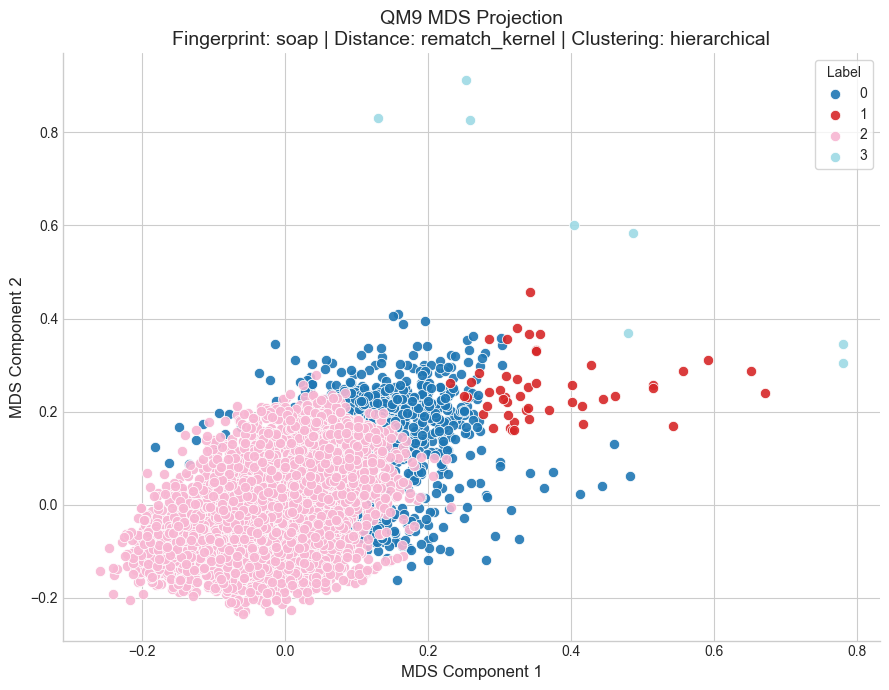

2026-05-09 13:20:09.894 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:605 - Saved MDS projection plot to figures/qm9/clustering/rematch_kernel/soap/mds_hierarchical_projection.png


In [40]:
_=plot_distance_matrix_projection(
    dist_matrix=rematch_kernel_dist_matrix,
    fingerprint="soap",
    distance_metric="rematch_kernel",
    projection_method=projection_method,
    dataset_name="qm9",
    labels=labels_hier_rematch,
    clustering_method="hierarchical"
)